__Лабораторная работа №11__

Решите пожалуйста следующую задачу.

1. Используйте подход Нейронных Сетей (библиотека pytorch) и метод обратного распространения ошибки.

для данных находящихся по ссылке https://drive.google.com/file/d/1LBDnhITL0Wqwp5G6M6IBI-SSz8BIoNec/view?pli=1
    
выходящей меткой (учителем) является столбец / атрибут - outcome.

Данный датасет мы рассматривали на лекции с одним внутренним слоем.

Постройте топологию Нейронной Сети: 

- c 3 внутренними слоями (количество нейронов в сети пожалуйста подберите сами)

- c 4 внутренними слоями (количество нейронов в сети пожалуйста подберите сами)

Сравните значения метрики качества (accuracy) между указанными топологиями.



---

In [1]:
# !pip install prompt-toolkit
#!pip install prompt-toolkit==3.0.5
# !pip install --upgrade pip

In [2]:
import numpy as np
from numpy import random as rng
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

tqdm.pandas()
np.set_printoptions(precision=2)

# читаем данные

https://drive.google.com/file/d/1LBDnhITL0Wqwp5G6M6IBI-SSz8BIoNec/view?usp=sharing

In [3]:
file_id = '1LBDnhITL0Wqwp5G6M6IBI-SSz8BIoNec'
url = f'https://drive.google.com/uc?id={file_id}'
df = pd.read_csv(url).convert_dtypes()
display(len(df))
display(df.info())
display(df.describe().T)
display(df.sample(3))

768

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    Int64  
 1   Glucose                   768 non-null    Int64  
 2   BloodPressure             768 non-null    Int64  
 3   SkinThickness             768 non-null    Int64  
 4   Insulin                   768 non-null    Int64  
 5   BMI                       768 non-null    Float64
 6   DiabetesPedigreeFunction  768 non-null    Float64
 7   Age                       768 non-null    Int64  
 8   Outcome                   768 non-null    Int64  
dtypes: Float64(2), Int64(7)
memory usage: 60.9 KB


None

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.0,1.0,3.0,6.0,17.0
Glucose,768.0,120.894531,31.972618,0.0,99.0,117.0,140.25,199.0
BloodPressure,768.0,69.105469,19.355807,0.0,62.0,72.0,80.0,122.0
SkinThickness,768.0,20.536458,15.952218,0.0,0.0,23.0,32.0,99.0
Insulin,768.0,79.799479,115.244002,0.0,0.0,30.5,127.25,846.0
BMI,768.0,31.992578,7.88416,0.0,27.3,32.0,36.6,67.1
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.0,24.0,29.0,41.0,81.0
Outcome,768.0,0.348958,0.476951,0.0,0.0,0.0,1.0,1.0


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
429,1,95,82,25,180,35.0,0.233,43,1
690,8,107,80,0,0,24.6,0.856,34,0
227,3,162,52,38,0,37.2,0.652,24,1


In [4]:
n_classes = len( df['Outcome'].unique() ) # список меток классов
display(n_classes)

2

- __Pregnancies__: Number of times pregnant
- __Glucose__: Plasma glucose concentration a 2 hours in an oral glucose tolerance test
- __BloodPressure__: Diastolic blood pressure (mm Hg)
- __SkinThickness__: Triceps skin fold thickness (mm)
- __Insulin__: 2-Hour serum insulin ($\mu$ U/ml)
- __BMI__: Body mass index ([ weight in kg ]/[ height in m ]$^2$)
- __DiabetesPedigreeFunction__: Diabetes pedigree function
- __Age__: Age (years)
- __Outcome__: Class variable (0 or 1)

# формируем датасеты

In [5]:
fet_cols = [
    'Pregnancies',
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age', 
]

X = np.array(df[fet_cols],dtype=np.float32)
target = np.array(df[['Outcome']],dtype=np.float32)

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,target,test_size=.1)
X_train, X_val,  y_train, y_val  = train_test_split(X_train,y_train,test_size=.1)

del X, target

display( X_train.shape, y_train.shape, X_test.shape, y_test.shape, X_val.shape, y_val.shape)

(621, 8)

(621, 1)

(77, 8)

(77, 1)

(70, 8)

(70, 1)

In [7]:
df_train = pd.DataFrame( np.hstack([X_train,y_train]), columns=fet_cols+['Outcome'] )
df_test  = pd.DataFrame( np.hstack([X_test, y_test ]), columns=fet_cols+['Outcome'] )
df_val   = pd.DataFrame( np.hstack([X_val,  y_val  ]), columns=fet_cols+['Outcome'] )
display( len(df_train), len(df_test),len(df_val), )

621

77

70

In [8]:
del X_train, y_train, X_test, y_test, X_val, y_val

In [9]:
# df_train

In [10]:
def binarization(d,n):
    return np.eye(n,dtype=np.float32)[np.array(d,dtype=np.uint16)]   
    # return np.eye(d.max()+1,dtype=np.float32)[np.array(d,dtype=np.uint16)] 

def get_bins(d, perc=[.25,.5,.75]):
    return [ (d.min()-1e+5), ]+ d.describe(perc).iloc[4:].unique().tolist() + [ (d.max()+1e+5), ]

def categorization(d,bins):
    return pd.cut( d, bins=bins, include_lowest=True, labels=range(len(bins)-1) ).astype(int)

----

In [11]:
## формируем векторы выхода для обучения сети

In [12]:
y_train = binarization(df_train['Outcome'].astype(np.uint8).values,n=n_classes)
y_val = binarization(df_val['Outcome'].astype(np.uint8).values,n=n_classes)
target_test = df_test['Outcome'].astype(np.uint8)

In [13]:
fet_scale = [ # признаки, которые будем нормировать
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
]
 
fet_cluster = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',    
]
    
fet_bin = [ # признаки, которые будем категоризовать
    'Age', 
    'Pregnancies', 
]

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler().fit( df_train[fet_scale].values)

---

In [15]:
# from sklearn.metrics.pairwise import PAIRWISE_DISTANCE_FUNCTIONS
# sorted(PAIRWISE_DISTANCE_FUNCTIONS.keys())

In [16]:
# from sklearn.metrics import pairwise_distances

# # pairwise_distances(df_train[fet_cluster].sample(5).values,  metric='euclidean', )
# pairwise_distances(df_train[fet_cluster].sample(5).values,  metric='cosine', )
# # pairwise_distances(df_train[fet_cluster].sample(5).values,  metric='cityblock', )
# # pairwise_distances(df_train[fet_cluster].sample(5).values,  metric='manhattan', )
# # pairwise_distances(df_train[fet_cluster].sample(5).values,  metric='l2', )
# # pairwise_distances(df_train[fet_cluster].sample(5).values,  metric='l1', )

In [17]:
# from sklearn.cluster import KMeans
# n_clusters = 9
# clusterizer = KMeans(n_clusters=n_clusters).fit(df_train[fet_cluster].values)

In [18]:
from sklearn.cluster import MeanShift
min_dist = 128.1
# min_dist = 94.1
# min_dist = 64.1
clusterizer = MeanShift(bandwidth=min_dist).fit(df_train[fet_cluster].values)
display( set(clusterizer.labels_) )
n_clusters = max(clusterizer.labels_)+1
display(n_clusters)
assert n_clusters > 1

{0, 1, 2}

3

In [19]:
# from sklearn.cluster import DBSCAN

# DBSCAN(
#     eps=0.5,
#     *,
#     min_samples=5,
#     metric='euclidean',
#     metric_params=None,
#     algorithm='auto',
#     leaf_size=30,
#     p=None,
#     n_jobs=None,
# )


# clusterizer = DBSCAN(metric='cityblock', eps=24.,).fit(df_train[fet_cluster].values)
# clusterizer = DBSCAN(metric='manhattan', eps=24.,).fit(df_train[fet_cluster].values)
# clusterizer = DBSCAN(metric='euclidean', eps=64.1,).fit(df_train[fet_cluster].values)

# clusterizer = DBSCAN(metric='cosine', eps=0.007,).fit(df_train[fet_cluster].values)
# display( set(clusterizer.labels_) )
# n_clusters = max(clusterizer.labels_+1)+1
# display(n_clusters)
# assert n_clusters > 2

In [20]:
# display( set( clusterizer.fit_predict(df_test[fet_cluster].values) ) )
# display( set( clusterizer.fit_predict(df_val[fet_cluster].values) ) )

---

In [21]:
bins = { c:get_bins( df_train[c],perc=[.25,.5,.75]) for c in fet_bin }
display(bins)

{'Age': [-99979.0, 24.0, 29.0, 41.0, 72.0, 100072.0],
 'Pregnancies': [-100000.0, 1.0, 3.0, 6.0, 17.0, 100017.0]}

In [22]:
# df_val[c]

In [23]:
# x_train = np.hstack([
#     scaler.transform( df_train[fet_scale].values ),
#     binarization( clusterizer.fit_predict(df_train[fet_scale].values)+1, n=n_clusters ),
#     np.hstack([ 
#         binarization( categorization( df_train[c], bins[c]), n=len(bins[c])-1 )
#         for c in fet_bin 
#     ]),
# ])

# x_val = np.hstack([
#     scaler.transform( df_val[fet_scale].values ),
#     binarization( clusterizer.fit_predict(df_val[fet_scale].values)+1, n=n_clusters ),
#     np.hstack([ 
#         binarization( categorization( df_val[c], bins[c]), n=len(bins[c])-1 )
#         for c in fet_bin 
#     ]),
# ])

# x_test = np.hstack([
#     scaler.transform( df_test[fet_scale].values ),
#     binarization( clusterizer.fit_predict(df_test[fet_scale].values)+1, n=n_clusters ),
#     np.hstack([ 
#         binarization( categorization( df_test[c], bins[c]), n=len(bins[c])-1 )
#         for c in fet_bin 
#     ]),
# ])

# display( x_train.shape, x_val.shape, x_test.shape )

In [24]:
x_train = np.hstack([
    scaler.transform( df_train[fet_scale].values ),
    binarization( clusterizer.predict(df_train[fet_scale].values), n=n_clusters ),
    np.hstack([ 
        binarization( categorization( df_train[c], bins[c]), n=len(bins[c])-1 )
        for c in fet_bin 
    ]),
])

x_val = np.hstack([
    scaler.transform( df_val[fet_scale].values ),
    binarization( clusterizer.predict(df_val[fet_scale].values), n=n_clusters ),
    np.hstack([ 
        binarization( categorization( df_val[c], bins[c]), n=len(bins[c])-1 )
        for c in fet_bin 
    ]),
])

x_test = np.hstack([
    scaler.transform( df_test[fet_scale].values ),
    binarization( clusterizer.predict(df_test[fet_scale].values), n=n_clusters ),
    np.hstack([ 
        binarization( categorization( df_test[c], bins[c]), n=len(bins[c])-1 )
        for c in fet_bin 
    ]),
])

display( x_train.shape, x_val.shape, x_test.shape )

(621, 19)

(70, 19)

(77, 19)

In [25]:
# до стандартизации
df_train[fet_scale].describe().T

,count,mean,std,min,25%,50%,75%,max
Glucose,621.0,121.426727,31.571167,0.000,99.000,117.000000,141.000000,199.000000
BloodPressure,621.0,69.304344,18.687044,0.000,64.000,72.000000,80.000000,114.000000
SkinThickness,621.0,20.507246,16.179697,0.000,0.000,23.000000,33.000000,99.000000
Insulin,621.0,81.156197,119.028015,0.000,0.000,29.000000,130.000000,846.000000
BMI,621.0,32.103058,7.640882,0.000,27.500,32.400002,36.599998,67.099998
DiabetesPedigreeFunction,621.0,0.475625,0.332365,0.078,0.244,0.383000,0.640000,2.420000


In [26]:
# после стандартизации
display( pd.DataFrame( x_train[:,:len(fet_scale)], columns=fet_scale).describe().T )

,count,mean,std,min,25%,50%,75%,max
Glucose,621.0,7.678537e-09,1.000806,-3.849228,-0.710927,-0.140327,0.620473,2.459073
BloodPressure,621.0,5.374976e-09,1.000806,-3.711674,-0.284080,0.144369,0.572818,2.393727
SkinThickness,621.0,-3.455342e-09,1.000806,-1.268490,-1.268490,0.154191,0.772748,4.855222
Insulin,621.0,1.535707e-08,1.000806,-0.682374,-0.682374,-0.438537,0.410686,6.430926
BMI,621.0,-3.071415e-09,1.000806,-4.204873,-0.602911,0.038894,0.589011,4.583915
DiabetesPedigreeFunction,621.0,3.071415e-09,1.000806,-1.197313,-0.697460,-0.278908,0.494961,5.854832


## выкидываем нулевые признаки

In [27]:
# колонки в матрице признаков, которые после преобразований получились полностью нулевые
fet_zero = np.vstack([
        np.abs(x_train).sum(axis=0)==0.,
        #np.abs(x_test).sum(axis=0)==0. ,
        #np.abs(x_val).sum(axis=0)==0. ,
    ]).T.any(axis=1)

display( fet_zero )

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
        True])

In [28]:
# выкидываем нулевые признаки
x_train = x_train[ :,~fet_zero ]
x_val = x_val[ :,~fet_zero ]
x_test = x_test[ :,~fet_zero ]

In [29]:
assert all( np.abs(x_train).sum(axis=0)>0. )

## проверка корреляции признаков

In [30]:
# import seaborn as sns
# sns.heatmap(pd.DataFrame(x_train).corr())

In [31]:
fet_corr = pd.DataFrame(x_train).corr()

def _color_red_or_green(val):
    color = 'red' if abs(val)>0.8 else ('blue' if abs(val)>0.5 else 'green')
    return 'color: %s' % color

display( fet_corr.style.applymap(_color_red_or_green) )

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16
0,1.000000,0.149910,0.073935,0.333948,0.222536,0.162100,-0.320774,0.293810,0.137466,-0.216022,-0.035686,0.096846,0.166229,-0.066884,-0.084342,0.049929,0.111555
1,0.149910,1.000000,0.206773,0.091503,0.275152,0.088522,-0.058889,0.056640,0.015034,-0.152821,-0.090605,0.017413,0.235876,-0.066068,-0.132146,0.086632,0.122088
2,0.073935,0.206773,1.000000,0.428838,0.403358,0.222275,-0.200678,0.193844,0.048094,0.055859,0.069722,0.000875,-0.130252,0.118789,0.020324,-0.109571,-0.045515
3,0.333948,0.091503,0.428838,1.000000,0.209041,0.193103,-0.766725,0.684494,0.395730,0.019244,0.021949,-0.011269,-0.030788,0.050550,0.008855,-0.043747,-0.022489
4,0.222536,0.275152,0.403358,0.209041,1.000000,0.156105,-0.160033,0.146383,0.069328,-0.130317,0.100326,0.026386,0.012005,0.083309,-0.109823,0.004288,0.012112
5,0.162100,0.088522,0.222275,0.193103,0.156105,1.000000,-0.091143,0.061845,0.120782,-0.096159,0.009598,0.054927,0.036299,0.044019,-0.017814,-0.057141,0.025588
6,-0.320774,-0.058889,-0.200678,-0.766725,-0.160033,-0.091143,1.000000,-0.966373,-0.238049,0.025015,-0.039760,0.022191,-0.010167,-0.009459,0.030307,-0.000462,-0.019518
7,0.293810,0.056640,0.193844,0.684494,0.146383,0.061845,-0.966373,1.000000,-0.019707,-0.027793,0.050972,-0.026036,0.005950,-0.003386,-0.021201,-0.004371,0.029814
8,0.137466,0.015034,0.048094,0.395730,0.069328,0.120782,-0.238049,-0.019707,1.000000,0.007718,-0.037935,0.012057,0.017055,0.049565,-0.037762,0.018304,-0.036721
9,-0.216022,-0.152821,0.055859,0.019244,-0.130317,-0.096159,0.025015,-0.027793,0.007718,1.000000,-0.342415,-0.370498,-0.343978,0.361374,0.145332,-0.234849,-0.322792


In [32]:
# удаляем признаки с высокой корреляцией
# fet_corr_large_idx = np.where( np.tril(fet_corr.abs().values>0.8,-1) )[0]
# display( fet_corr_large_idx )

# display(( x_train.shape, x_val.shape, x_test.shape ))

# if len(fet_corr_large_idx)>0:
#     x_train = np.delete(x_train, np.s_[fet_corr_large_idx], axis=1)
#     x_val = np.delete(x_val,   np.s_[fet_corr_large_idx], axis=1)
#     x_test = np.delete(x_test,  np.s_[fet_corr_large_idx], axis=1)

#     display(( x_train.shape, x_val.shape, x_test.shape ))

---

In [33]:
n_fet = x_train.shape[1]
display(n_fet)

17

# строим модель классификатора

In [34]:
import torch
from torch import nn
#from torch import tanh
#from torch import sigmoid
from torch import relu
from torch import softmax

In [35]:
# три обрабатывающих слоя 

class MLP3(nn.Module): 
    
    def __init__(self,input_size,output_size):
        super().__init__()
        self._dense1 = nn.Linear(input_size,128) # первый - обрабатывающий  слой 
        self._dp1 = nn.Dropout(p=0.1, inplace=False)
        self._dense2 = nn.Linear(128,16) # второй - обрабатывающий/скрытый слой
        self._dp2 = nn.Dropout(p=0.1, inplace=False)
        self._dense3 = nn.Linear(16,output_size) # третий - обрабатывающий/выходной слой
        # self._dp3 = nn.Dropout(p=0.1, inplace=False)


    def forward(self,x):
        o = self._dp1( relu(self._dense1(x)) )
        o = self._dp2( relu(self._dense2(o)) )
        # o = self._dp3( self._dense3(o) )
        o = softmax( self._dense3(o), dim=1)
        return o
    
    def predict(self, x):    
        return self.forward(x)
    

In [36]:
# # четыре обрабатывающих слоя 
# class MLP4(nn.Module): 
    
#     def __init__(self,input_size,output_size):
#         super().__init__()
#         self.dense1 = nn.Linear(input_size,128) # первый - обрабатывающий  слой 
#         self.dense2 = nn.Linear(128,32) # второй - обрабатывающий/скрытый слой
#         self.dense3 = nn.Linear(32,16) # третий - обрабатывающий/скрытый слой
#         self.dense4 = nn.Linear(16,output_size) # четвёртый - обрабатывающий/выходной слой

#     def forward(self,x):
#         o = relu(self.dense1(x))
#         o = relu(self.dense2(o))
#         o = relu(self.dense3(o))
#         o = softmax(self.dense4(o),dim=1)
#         return o
    
#     def predict(self, x):    
#         return self.forward(x)
    

In [37]:
model = MLP3( input_size=n_fet, output_size=n_classes, )
# model = MLP4( input_size=n_fet, output_size=n_classes, )

# обучаем модель

In [38]:
# используем GPU если есть
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
display(device)

model = model.to(device)

device(type='cuda', index=0)

In [39]:
# criterion = nn.MSELoss() # ф-ция потери для выхода sigmoid
criterion = nn.CrossEntropyLoss() # ф-ция потери для выхода softmax

In [40]:
from torch.utils.data import TensorDataset

# пакуем учебные данные в формат Torch
ds_train = TensorDataset( torch.Tensor(x_train), torch.Tensor(y_train) )

In [41]:
from sklearn.metrics import accuracy_score

# будем мониторить погрешность модели по ходу обучения
def accuracy(x,y):
    with torch.set_grad_enabled(False):
        o = np.argmax( model.predict(torch.Tensor(x).to(device)).cpu().numpy(),axis=1 )
    return accuracy_score(y[:,1],o)

acc_train_history = [ accuracy(x_train,y_train) ] # начальное значение погрешности
acc_val_history = [ accuracy(x_val,y_val) ] # начальное значение погрешности

display( acc_train_history, acc_val_history,  )

[0.6409017713365539]

[0.6285714285714286]

In [42]:
# считаем начальное значение ф-ции потери
with torch.set_grad_enabled(False):
    loss = criterion( 
            torch.Tensor(y_train).to(device), 
            model.predict( torch.Tensor(x_train).to(device) ) 
        ).cpu().numpy().flatten()[0]
    
loss_history = [ loss ] 
display( loss_history )

[0.79648787]

In [43]:
from torch import optim

optimizer = optim.Adam( model.parameters(), lr=1e-3 ) # метод оптимизации ф-ции потери
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=64, gamma=0.95)

## основной цикл обучения

In [44]:
from torch.utils.data import DataLoader # генератор батчей

In [45]:
%%time

n_epoch = 1024*7 # количество эпох обучения
acc_min = .95 # порог допустимой погрешности модели

lr_history = [ ]

for i in tqdm(range(n_epoch)): 
    loss_batch = []
    for x,y in DataLoader(ds_train, 
                          batch_size=len(y_train)//4, 
                          shuffle=True): # получаем батч учебных примеров

        optimizer.zero_grad() # очищаем предыдущее значение градиента
        out = model.forward(x.to(device)) # считаем выход модели
        loss = criterion( y.to(device),out ) # вычисляем значение ф-ции потери
        loss_batch.append(loss.item()) # дополняем историю изменения значений ф-ции потери
        loss.backward()  # вычисляем текущее значение градиента ф-ции потери
        optimizer.step() # корректируем параметры модели
    
    lr_history += lr_scheduler.get_last_lr()
    loss_history.append(np.mean(loss_batch)) # дополняем историю изменения значений ф-ции потери
    acc_train_history.append( accuracy(x_train,y_train) ) #значение погрешности
    acc_val_history.append( accuracy(x_val,y_val) ) #значение погрешности
    
    lr_scheduler.step()
    
    if acc_val_history[-1] > acc_min: # проверяем достижение минимального порога погрешности модели
        print('step %i/%i: loss %.03f, acc threshold %.03f reached\n'%(i+1,n_epoch,loss_history[-1],acc_min))
        break
        
    if (i>n_epoch*0.25) : 
        if (acc_val_history[-10] > acc_val_history[-1]) and (acc_val_history[-1]<acc_train_history[-1] ) : 
            print('step %i/%i: loss %.03f, val acc down \n'%(i+1,n_epoch,loss_history[-1]))
            break    

  0%|          | 0/7168 [00:00<?, ?it/s]

step 1794/7168: loss 0.621, val acc down 

CPU times: user 16.8 s, sys: 63.4 ms, total: 16.8 s
Wall time: 17.5 s


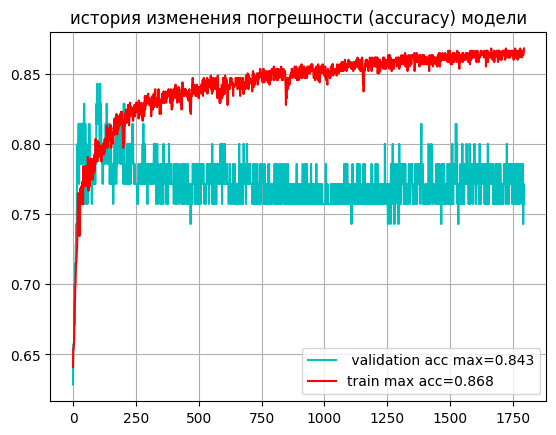

In [46]:
# история изменения значений погрешности модели
plt.plot(acc_val_history,label=' validation acc max=%.3f'%(max(acc_val_history)),c='c')
plt.plot(acc_train_history,label='train max acc=%.3f'%(max(acc_train_history)),c='r')
plt.title('история изменения погрешности (accuracy) модели')
plt.grid()
plt.legend()

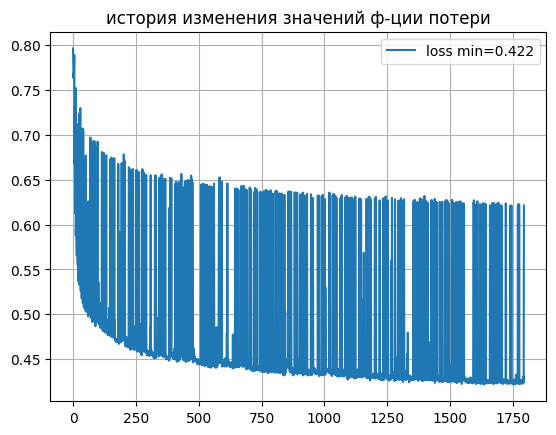

In [47]:
# история изменения значений ф-ции потери
plt.plot(loss_history,label='loss min=%.3f'%(min(loss_history)))
plt.grid()
plt.title('история изменения значений ф-ции потери')
plt.legend()

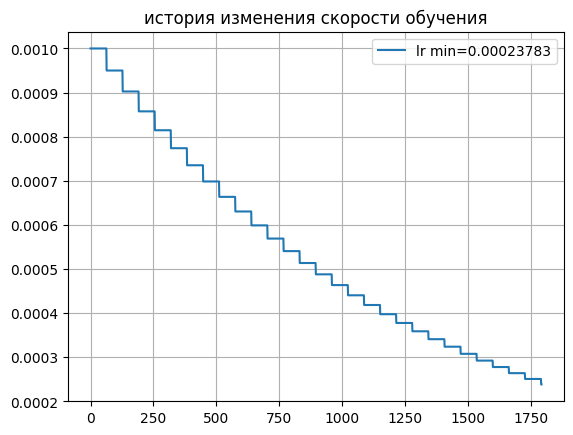

In [48]:
# история изменения скорости обучения
plt.plot(lr_history,label='lr min=%.8f'%(min(lr_history)))
plt.grid()
plt.title('история изменения скорости обучения')
plt.legend()

# тестируем модель

In [49]:
# предииктим метки для тестового датасета
with torch.set_grad_enabled(False):
    score_test = model.predict( torch.Tensor(x_test).to(device)).cpu().numpy()[:,1]

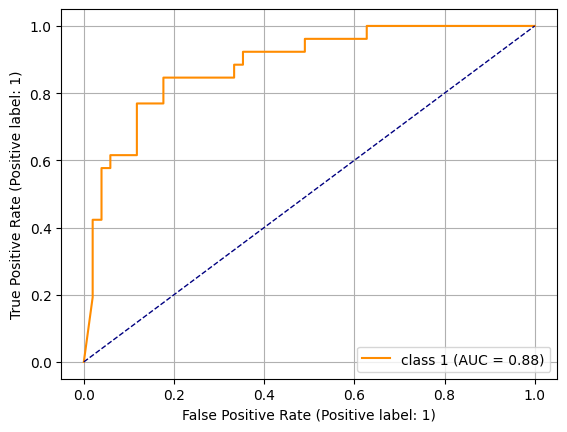

In [50]:
# рисуем ROC/AUC - зависимость точности и полноты при изменении порога скора
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions( target_test, score_test, name="class 1", color="darkorange", )
plt.plot([0,1],[0,1], color='navy', lw=1, linestyle='--')
plt.grid()

In [51]:
# определяем оптимальный порог скора 
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve( target_test, score_test )

#  максимальное количество True Positive при минимальном количестве False Positive
optimal_threshold = thresholds[ np.argmax( np.abs(tpr-fpr) )  ]
display(optimal_threshold)

0.00018176717

In [52]:
# применяем оптимальный порог скора, предсказываем класс объектов
target_pred = (score_test > optimal_threshold).astype(np.uint8)
# target_pred = (score_test > 0.5).astype(np.uint8)

              precision    recall  f1-score   support

           0       0.89      0.82      0.86        51
           1       0.70      0.81      0.75        26

    accuracy                           0.82        77
   macro avg       0.80      0.82      0.80        77
weighted avg       0.83      0.82      0.82        77



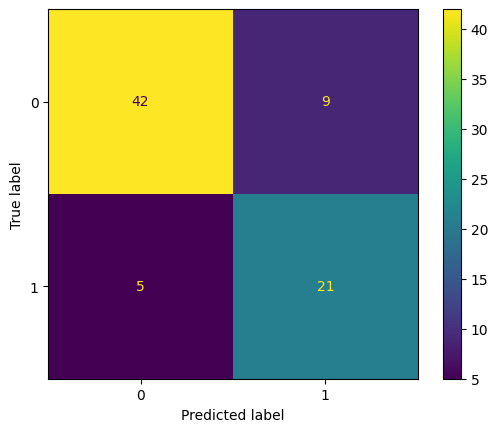

In [53]:
# оценка результатов тестирования

from sklearn.metrics import classification_report
print(classification_report(target_test,target_pred))

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay( confusion_matrix=confusion_matrix(target_test,target_pred), ).plot()